In [2]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 
from src import util_process_prolific as util_process

from tqdm.auto import tqdm
import multiprocessing as mp
from scipy.stats import norm
from scipy.special import ndtri

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## Load participant data and meta files 

In [4]:
### Load in experiment manifests with full transcripts
path_to_manifest = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta_transcripts.pdpkl')
df_w_transcripts = pd.read_pickle(path_to_manifest)

# unpack distractor words to individual columns

dist_1_word, dist_2_word = zip(*df_w_transcripts.distractor_word.apply(util_process.unpack_dist_words))

df_w_transcripts['distractor_1_word'] = dist_1_word
df_w_transcripts['distractor_2_word'] = dist_2_word
df_w_transcripts['targ_src_stem'] = df_w_transcripts.excerpt_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_1_src_stem'] = df_w_transcripts.excerpt_distractor_1_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_2_src_stem'] = df_w_transcripts.excerpt_distractor_2_src_fn.apply(util_process.slice_transcript_path)


In [5]:
def get_target_transcript(fname):
    return df_w_transcripts.loc[df_w_transcripts['targ_src_stem'].eq(fname), 'target_transcripts'].values[0]

def get_distractor_tscript(fname):
    if df_w_transcripts['dist_1_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_1_src_stem'].eq(fname), 'distractor_1_transcripts'].values[0]
    elif df_w_transcripts['dist_2_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_2_src_stem'].eq(fname), 'distractor_2_transcripts'].values[0]
    return tscript

def get_trial_task_type(target_loc):
    if isinstance(target_loc, list):
        if target_loc[1][0] == 0: # if target is at 0 azimuth 
            task = 'elevation direction'
        elif target_loc[1][0] != 0:
            task = 'azimuth direction'
    else:
        task = 'overlap'
    return task 
            

In [6]:
part_results

NameError: name 'part_results' is not defined

In [7]:
pd.read_csv(part_results[4]).shape

NameError: name 'part_results' is not defined

In [8]:
path_to_parts = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/localization_check_data/localization_check_v01')
part_results = sorted(list(path_to_parts.glob("*.csv")))

path_to_meta_data = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/localization_check_v01/')
meta_files = sorted(list(path_to_meta_data.glob("*meta.pkl")))

# meta_files
manifest_dict = {}
for meta_file in meta_files:
    if 'pilot' in meta_file.parent.stem:
        part_name = "pilot_" + "_".join(meta_file.stem.split('_')[:2])

    else:
        part_name = "_".join(meta_file.stem.split('_')[:2])
    manifest_dict[part_name] = meta_file


dfs = []
for result_file in part_results:
    try:
        part_name = result_file.stem
        # print(part_name)
        # remove space 
        if 'copy' in part_name:
            print(part_name)
            continue
        if 'pilot' in result_file.parent.stem:
            part_name = "pilot_" + "_".join(result_file.stem.split('_')[:2])
        if ' ' in part_name:
            part_name = part_name.split(' ')[0]
        if '033' in part_name or '004' in part_name:
            continue
        if '0010' in part_name:
            continue
        if 'participant_001' == part_name:
            print(part_name)
            continue
        # get digits in string pattern participant_xxx_ or participant_XXX. 
        part_ix = int(re.search(r'\d+', part_name).group())
        part_name_str = f"participant_{part_ix:03d}"
        manifest_file = manifest_dict[part_name_str]
        # part_df = pd.read_csv(result_file)
        # part_df = part_df
        part_df = util_process.get_part_df_loc_check(result_file)
        manifest_df = util_process.get_manifest_df(manifest_file)
        # merge on shared trial_index
        part_df = pd.merge(part_df[['trial_num', 'stimulus', 'response', 'correct_response', 'correct']],
                manifest_df, left_on='trial_num', right_on='trial_num', how='left')
        part_df['participant'] = part_name_str
        part_df['task'] = part_df['target_loc'].apply(get_trial_task_type)
        dfs.append(part_df)

    except:
        continue

results_df = pd.concat(dfs, ignore_index=True)
results_df.loc[results_df.task == 'elevation direction', "direction_label"] = results_df.loc[results_df.task == 'elevation direction', ['target_elev', 'distractor_elev']].apply(lambda x: int((x[0] < x[1])), axis=1) # map: above = 0 below = 1 
results_df.loc[results_df.task == 'azimuth direction', "direction_label"] = results_df.loc[results_df.task == 'azimuth direction', ['target_azim', 'distractor_azim']].apply(lambda x: int((x[0] > x[1])), axis=1) # map: above = 0 below = 1 
results_df.loc[results_df.task == 'overlap', "overlap_label"] = results_df.loc[results_df.task == 'overlap', ['target_elev', 'target_azim', 'distractor_elev', 'distractor_azim']].apply(lambda x: int((x[0] != x[2]) or (x[1] != x[3]) ), axis=1)  # co-located = 0, separated = 1 
results_df = results_df.drop_duplicates(subset=['participant', 'trial_num']).reset_index(drop=True)


participant_001
participant_0010-239_copy
participant_001_0-239_copy


## Co-location analysis

        participant   d_prime  delta  Condition
0   participant_001  0.273376     10  Elevation
1   participant_001  3.124125     60  Elevation
2   participant_001  3.124125     10    Azimuth
3   participant_001  3.124125     60    Azimuth
4   participant_002 -0.238560     10  Elevation
5   participant_002  2.612189     60  Elevation
6   participant_002  1.567392     10    Azimuth
7   participant_002  2.612189     60    Azimuth
8   participant_003  0.398739     10  Elevation
9   participant_003  1.805952     60  Elevation
10  participant_003  2.850748     10    Azimuth
11  participant_003  2.850748     60    Azimuth


Text(0.5, 1.1, 'Detecting talker separation (N=3)')

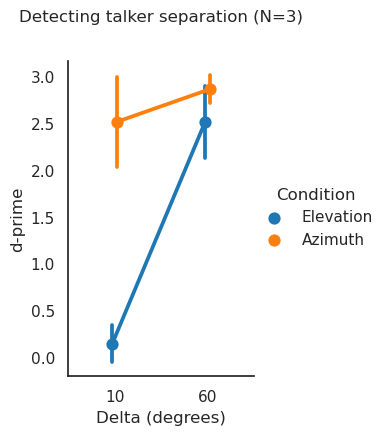

In [10]:
coloc_results = results_df[(results_df.task == 'overlap')].copy()
coloc_results['correct'] = coloc_results['overlap_label'] == coloc_results['response']
# coloc_summary = coloc_results.groupby(['participant',  'elev_delta']).correct.mean().reset_index()
# coloc_summary

## measure d prime at 10 and 60 degree deltas for each participant
d_prime = []
for (part, data) in coloc_results.groupby(['participant']):
    # get false alarm rate 
    part_elev_data = data[(data.azim_delta == 0)]
    
    fa = 1 - part_elev_data[(part_elev_data.elev_delta == 0) & (part_elev_data.azim_delta == 0)].correct.mean()
    hit_10 = np.clip(part_elev_data[part_elev_data.elev_delta == 10].correct.mean(), a_min=0.01, a_max=0.99)
    d_prime_10 = ndtri(hit_10) - ndtri(fa)
    d_prime.append({'participant': part, 'd_prime': d_prime_10, 'delta': 10, 'Condition': 'Elevation'})

    hit_60 = np.clip(part_elev_data[part_elev_data.elev_delta == 60].correct.mean(), a_min=0.01, a_max=0.99)
    d_prime_60 = ndtri(hit_60) - ndtri(fa)
    d_prime.append({'participant': part, 'd_prime': d_prime_60, 'delta': 60, 'Condition': 'Elevation'})

    ## measure for azimuth 
    part_azim_data = data[(data.elev_delta == 0)]

    hit_10 = np.clip(part_azim_data[part_azim_data.azim_delta == 10].correct.mean(), a_min=0.01, a_max=0.99)
    d_prime_10 = ndtri(hit_10) - ndtri(fa)
    d_prime_10 = ndtri(hit_10) - ndtri(fa)
    d_prime.append({'participant': part, 'd_prime': d_prime_10, 'delta': 10, 'Condition': 'Azimuth'})

    hit_60 = np.clip(part_azim_data[part_azim_data.azim_delta == 60].correct.mean(), a_min=0.01, a_max=0.99)
    d_prime_60 = ndtri(hit_60) - ndtri(fa)
    d_prime.append({'participant': part, 'd_prime': d_prime_60, 'delta': 60, 'Condition': 'Azimuth'})

d_prime_df = pd.DataFrame(d_prime)
print(d_prime_df)
N = d_prime_df.participant.nunique()
# d_prime_df = pd.DataFrame(d_prime)
# plot 
sns.set_context('notebook')
sns.set_style('white')
g = sns.catplot(data=d_prime_df, kind='point', x='delta', y='d_prime',
                  hue='Condition',  dodge=True,
                   aspect=0.75, height=4,
                    errorbar='se')
g.set_axis_labels('Delta (degrees)', 'd-prime')
# g.set(ylim=(0, 3))
plt.title(f'Detecting talker separation (N={N})', y=1.1)



### Direction difference 

In [ ]:
##### Look at percent correct 
direction_trials = results_df[results_df.task != 'overlap'].copy()
direction_trials.loc[direction_trials.task == 'elevation direction', "delta"] = direction_trials.loc[direction_trials.task == 'elevation direction', 'elev_delta']
direction_trials.loc[direction_trials.task == 'azimuth direction', "delta"] = direction_trials.loc[direction_trials.task == 'azimuth direction', 'azim_delta']
direction_trials["delta"] = direction_trials["delta"].astype(int)
# direction_trials['cue_azim'], direction_trials['cue_elev'] = zip(*direction_trials['target_loc'].apply(lambda x: x[0]))
# direction_trials['elev_delta_rel'] =  direction_trials['distractor_elev'] - direction_trials['target_elev']
direction_summary = direction_trials.groupby(['participant',  'delta', 'task']).agg({"correct":'mean'}).reset_index()
print(direction_summary)
# Plot summary 
hue_order = ['elevation direction', 'azimuth direction']
sns.set_context('notebook')
sns.set_style('white')
g = sns.catplot(data=direction_summary, kind='point', x='delta', y='correct', 
                hue='task', hue_order=hue_order, dodge=True,
                 aspect=.75, height=4, errorbar='se') 
g.set_axis_labels('Delta (degrees)', 'Prop. correct')
g.set(ylim=(0.4, 1))
# add h line at chance
plt.axhline(0.5, linestyle='--', color='k')
plt.title(f'Report target talker direction (N={N})', y=1.1)


        participant delta                 task correct      
                                                  mean count
0   participant_001    10    azimuth direction   0.725    40
1   participant_001    10  elevation direction   0.625    40
2   participant_001    60    azimuth direction   0.950    40
3   participant_001    60  elevation direction   0.950    40
4   participant_002    10    azimuth direction   0.700    40
5   participant_002    10  elevation direction   0.475    40
6   participant_002    60    azimuth direction   0.750    40
7   participant_002    60  elevation direction   0.775    40
8   participant_003    10    azimuth direction   0.800    40
9   participant_003    10  elevation direction   0.400    40
10  participant_003    60    azimuth direction   0.900    40
11  participant_003    60  elevation direction   0.650    40


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

Text(0.5, 1.1, 'Report elevation direction (N=4)')

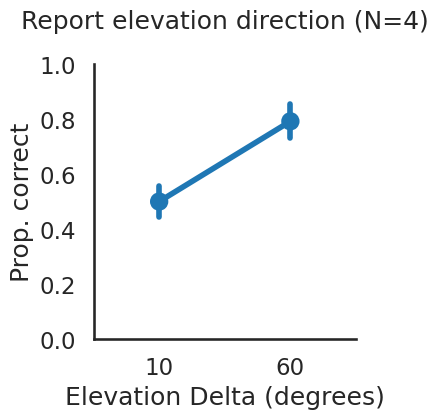

In [188]:
##### Look at percent correct 
direction_trials = results_df[results_df.task == 'elevation direction'].copy()
direction_trials['cue_azim'], direction_trials['cue_elev'] = zip(*direction_trials['target_loc'].apply(lambda x: x[0]))
direction_trials['elev_delta_rel'] =  direction_trials['distractor_elev'] - direction_trials['target_elev']
direction_summary = direction_trials.groupby(['participant',  'cue_elev', 'elev_delta_rel',  'target_elev', 'elev_delta']).correct.mean().reset_index()
# Plot summary 
sns.set_context('talk')
sns.set_style('white')
g = sns.catplot(data=direction_summary, kind='point', x='elev_delta', y='correct',   aspect=1, height=4, errorbar='se')
g.set_axis_labels('Elevation Delta (degrees)', 'Prop. correct')
g.set(ylim=(0, 1))
plt.title(f'Report elevation direction (N={N})', y=1.1)


Text(0.5, 1.1, 'Report azimuth direction (N=4)')

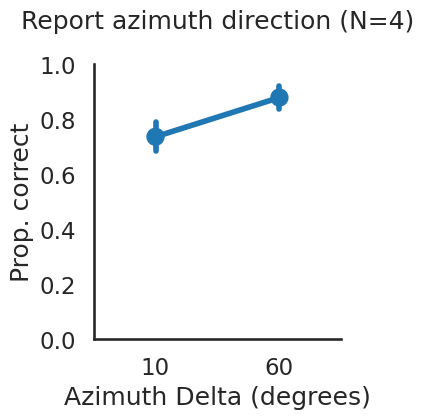

In [189]:
##### Look at percent correct 
direction_trials = results_df[results_df.task == 'azimuth direction'].copy()
direction_trials['cue_azim'], direction_trials['cue_azim'] = zip(*direction_trials['target_loc'].apply(lambda x: x[0]))
direction_trials['azim_delta_rel'] =  direction_trials['distractor_azim'] - direction_trials['target_azim']
direction_summary = direction_trials.groupby(['participant',  'cue_azim', 'azim_delta_rel',  'target_azim', 'azim_delta']).correct.mean().reset_index()
# Plot summary 
sns.set_context('talk')
sns.set_style('white')
g = sns.catplot(data=direction_summary, kind='point', x='azim_delta', y='correct',   aspect=1, height=4, errorbar='se')
g.set_axis_labels('Azimuth Delta (degrees)', 'Prop. correct')
g.set(ylim=(0, 1))
plt.title(f'Report azimuth direction (N={N})', y=1.1)


In [27]:
direction_summary

,participant,cue_elev,elev_delta_rel,target_elev,elev_delta,correct
0,participant_001,0,-60,40,60,0.043478
1,participant_001,0,-10,-10,10,0.400000
2,participant_001,0,-10,40,10,0.500000
3,participant_001,0,10,-20,10,0.700000
4,participant_001,0,10,30,10,0.250000
5,participant_001,0,60,-20,60,0.764706
6,participant_002,0,-60,40,60,0.217391
7,participant_002,0,-10,-10,10,0.400000
8,participant_002,0,-10,40,10,0.333333
9,participant_002,0,10,-20,10,0.800000


In [ ]:
direction_summary

,participant,cue_elev,elev_delta_rel,target_elev,elev_delta,correct
0,participant_001,0,-60,40,60,0.043478
1,participant_001,0,-10,-10,10,0.400000
2,participant_001,0,-10,40,10,0.500000
3,participant_001,0,10,-20,10,0.700000
4,participant_001,0,10,30,10,0.250000
5,participant_001,0,60,-20,60,0.764706
6,participant_002,0,-60,40,60,0.217391
7,participant_002,0,-10,-10,10,0.400000
8,participant_002,0,-10,40,10,0.333333
9,participant_002,0,10,-20,10,0.800000


In [203]:
direction_summary[direction_summary['elev_delta'] == 60].correct.mean()

0.4460517902813299

In [24]:
# # Plot summary 
# sns.set_context('talk')
# sns.set_style('white')
# direction_summary['loc_re_cue'] = (direction_summary['target_elev'] > direction_summary['cue_elev']).astype('int')

# direction_summary['loc_re_cue'] = direction_summary['loc_re_cue'].replace({0: 'Target below cue', 1: 'Target above cue'})
# g = sns.catplot(data=direction_summary, kind='point', x='elev_delta_rel', y='correct', col='loc_re_cue', aspect=1, height=4, errorbar='se')
# g.set_axis_labels('Elevation Delta (degrees)', 'Percent Correct')
# g.set_titles('{col_name}')
# g.set(ylim=(0, 1))


In [23]:
direction_summary.loc_re_cue.value_counts()

Target above cue    9
Target below cue    9
Name: loc_re_cue, dtype: int64